<a href="https://colab.research.google.com/github/amandaasyln/Network-Stability/blob/main/KLASIFIKASI%20JARINGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
# Membaca Dataset

df = pd.read_csv("monitoring.csv")
df

,Waktu,Ping(ms),Download(Mbps),Upload(Mbps),PacketLoss(%),Jitter(ms),Status
0,2026-05-09 16:19:01,80.00,20.64,15.61,0.00,9.70,Stabil
1,2026-05-09 16:24:01,36.31,25.61,18.55,0.20,1.00,Stabil
2,2026-05-09 16:29:01,26.98,16.04,13.26,0.00,13.72,Stabil
3,2026-05-09 16:34:01,22.87,23.99,23.49,0.00,11.64,Stabil
4,2026-05-09 16:39:01,55.58,29.40,16.14,0.00,13.37,Stabil
...,...,...,...,...,...,...,...
6995,2026-06-02 23:14:01,57.47,16.06,6.81,2.92,39.64,Tidak Stabil
6996,2026-06-02 23:19:01,167.96,10.51,1.76,5.46,41.29,Tidak Stabil
6997,2026-06-02 23:24:01,231.22,4.07,2.28,15.60,79.26,Tidak Stabil
6998,2026-06-02 23:29:01,95.00,15.13,10.84,0.57,81.98,Tidak Stabil


In [ ]:
# ENCODE LABEL STATUS

df["Status"] = df["Status"].map({
    "Stabil": 1,
    "Tidak Stabil": 0
})

df.head()

,Waktu,Ping(ms),Download(Mbps),Upload(Mbps),PacketLoss(%),Jitter(ms),Status
0,2026-05-09 16:19:01,80.00,20.64,15.61,0.0,9.70,1
1,2026-05-09 16:24:01,36.31,25.61,18.55,0.2,1.00,1
2,2026-05-09 16:29:01,26.98,16.04,13.26,0.0,13.72,1
3,2026-05-09 16:34:01,22.87,23.99,23.49,0.0,11.64,1
4,2026-05-09 16:39:01,55.58,29.40,16.14,0.0,13.37,1


In [ ]:
#Ambil Fitur QoS

data_len = df[[
    "Ping(ms)",
    "Download(Mbps)",
    "Upload(Mbps)",
    "PacketLoss(%)",
    "Jitter(ms)"
]]

In [ ]:
#cek missing value
df.isna() .sum()

,0
Waktu,0
Ping(ms),0
Download(Mbps),0
Upload(Mbps),0
PacketLoss(%),0
Jitter(ms),0
Status,0


In [ ]:
#menghilangkan nilai null
df = df.dropna()
df

,Waktu,Ping(ms),Download(Mbps),Upload(Mbps),PacketLoss(%),Jitter(ms),Status
0,2026-05-09 16:19:01,80.00,20.64,15.61,0.00,9.70,Stabil
1,2026-05-09 16:24:01,36.31,25.61,18.55,0.20,1.00,Stabil
2,2026-05-09 16:29:01,26.98,16.04,13.26,0.00,13.72,Stabil
3,2026-05-09 16:34:01,22.87,23.99,23.49,0.00,11.64,Stabil
4,2026-05-09 16:39:01,55.58,29.40,16.14,0.00,13.37,Stabil
...,...,...,...,...,...,...,...
6995,2026-06-02 23:14:01,57.47,16.06,6.81,2.92,39.64,Tidak Stabil
6996,2026-06-02 23:19:01,167.96,10.51,1.76,5.46,41.29,Tidak Stabil
6997,2026-06-02 23:24:01,231.22,4.07,2.28,15.60,79.26,Tidak Stabil
6998,2026-06-02 23:29:01,95.00,15.13,10.84,0.57,81.98,Tidak Stabil


In [ ]:
# normalisasi data
sc = MinMaxScaler(feature_range=(0,1))

scaled_data = sc.fit_transform(data_len)

scaled_data

array([[0.20640119, 0.36480457, 0.3887218 , 0.        , 0.04860335],
       [0.08616562, 0.45350705, 0.46240602, 0.00865426, 0.        ],
       [0.06048931, 0.28270569, 0.32982456, 0.        , 0.07106145],
       ...,
       [0.62256103, 0.06907014, 0.05463659, 0.67503245, 0.4372067 ],
       [0.24768143, 0.26646439, 0.26917293, 0.02466465, 0.45240223],
       [0.57489611, 0.09834017, 0.02180451, 0.58675898, 0.22944134]])

In [ ]:
#Pemisah Dataset
training_data = scaled_data[0:int(len(scaled_data)*0.7)]
testing_data = scaled_data[int(len(scaled_data)*0.7):]

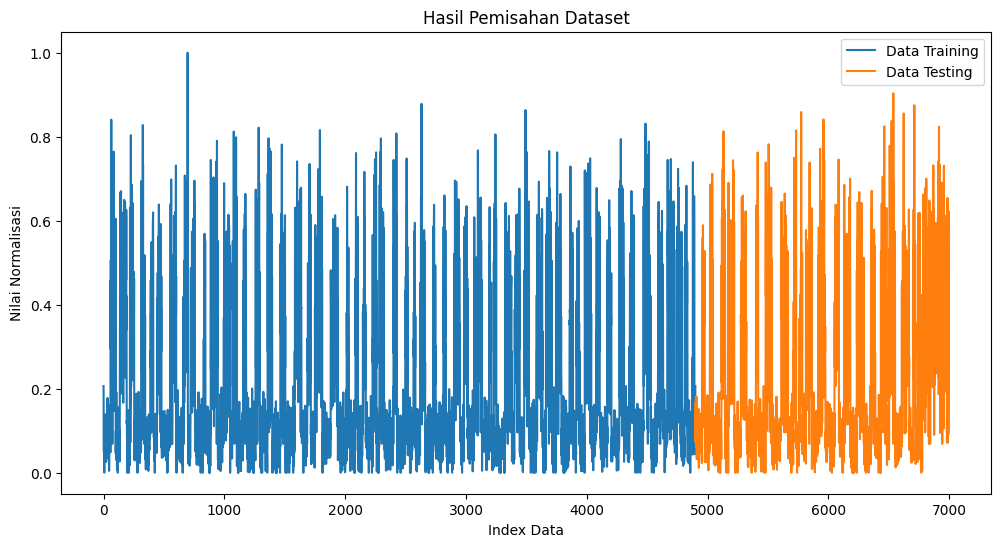

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    range(len(training_data)),
    training_data[:,0],
    label='Data Training'
)

plt.plot(
    range(len(training_data),
    len(training_data)+len(testing_data)),
    testing_data[:,0],
    label='Data Testing'
)

plt.title("Hasil Pemisahan Dataset")
plt.xlabel("Index Data")
plt.ylabel("Nilai Normalisasi")
plt.legend()

plt.show()

In [ ]:
#PEMBENTUKAN SEQUENCE TRAINING

sequence = 30

x_train = []
y_train = []

for i in range(sequence, len(training_data)):
    x_train.append(training_data[i-sequence:i])
    y_train.append(df["Status"].iloc[i])

x_train = np.array(x_train).astype(float)
y_train = np.array(y_train).astype(int)

print(x_train.shape)
print(y_train.shape)

(4870, 30, 5)
(4870,)


In [ ]:
#PEMBENTUKAN SEQUENCE TESTING


x_test = []
y_test = []

start_index_testing = int(len(scaled_data) * 0.7)

for i in range(sequence, len(testing_data)):
    x_test.append(testing_data[i-sequence:i])
    y_test.append(df["Status"].iloc[start_index_testing + i])

x_test = np.array(x_test).astype(float)
y_test = np.array(y_test).astype(int)

print(x_test.shape)
print(y_test.shape)

(2070, 30, 5)
(2070,)


In [ ]:
# MEMBANGUN MODEL LSTM
model = Sequential()

# Lapisan pertama
model.add(LSTM(
    units=60,
    return_sequences=True,
    input_shape=(x_train.shape[1], x_train.shape[2])
))
model.add(Dropout(0.2))

# Lapisan Kedua
model.add(LSTM(
    units=70,
    return_sequences=False
))
model.add(Dropout(0.2))

#Hidden layer Dense
model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

#Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 60)         │        15,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 60)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 70)             │        36,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,825 (214.16 KB)

 Trainable params: 54,825 (214.16 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#CLASS WEIGHT

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.1600762267746545), 1: np.float64(0.8787441356910862)}


In [ ]:
#TRAINING MODEL

history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_test, y_test),
    class_weight=class_weights
)

Epoch 1/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.8994 - loss: 0.3026 - val_accuracy: 0.9396 - val_loss: 0.1946
Epoch 2/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.9536 - loss: 0.1673 - val_accuracy: 0.9662 - val_loss: 0.1399
Epoch 3/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9663 - loss: 0.1383 - val_accuracy: 0.9749 - val_loss: 0.1183
Epoch 4/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9710 - loss: 0.1271 - val_accuracy: 0.9739 - val_loss: 0.1149
Epoch 5/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.9723 - loss: 0.1237 - val_accuracy: 0.9763 - val_loss: 0.1124
Epoch 6/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - accuracy: 0.9752 - loss: 0.1172 - val_accuracy: 0.9787 - val_loss: 0.1109
Epoch 7/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step - accuracy: 0.9743 - loss: 0.1174 - val_accuracy: 0.9773 - val_loss: 0.1125
Epoch 8/100
153/153 ━━━━━━━━━━━━━━━━━━━━ 23s 85ms/step - accuracy: 0.9754 - loss: 0.11

In [ ]:
# PREDIKSI MODEL

y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5).astype(int)
print(y_pred)

65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step
[[1]
 [1]
 [1]
 ...
 [0]
 [0]
 [0]]


In [ ]:
#EVALUASI MODEL

print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9768115942028985
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1051
           1       0.98      0.98      0.98      1019

    accuracy                           0.98      2070
   macro avg       0.98      0.98      0.98      2070
weighted avg       0.98      0.98      0.98      2070

[[1026   25]
 [  23  996]]


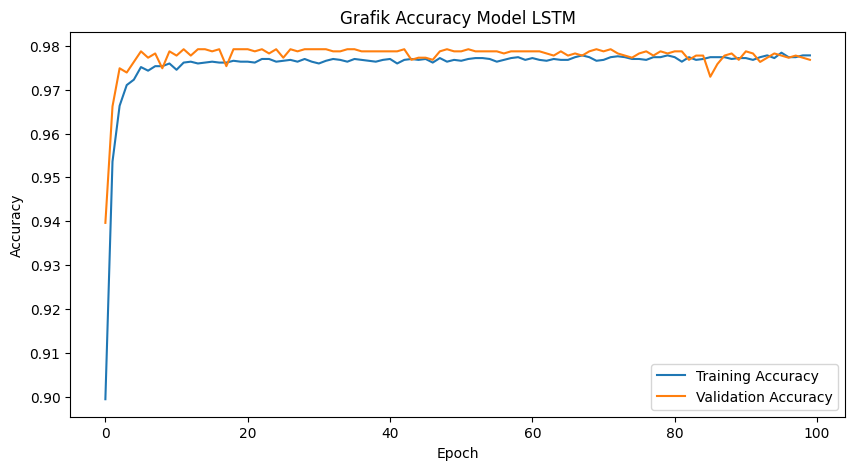

In [ ]:
#GRAFIK ACCURACY

plt.figure(figsize=(10,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Grafik Accuracy Model LSTM")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

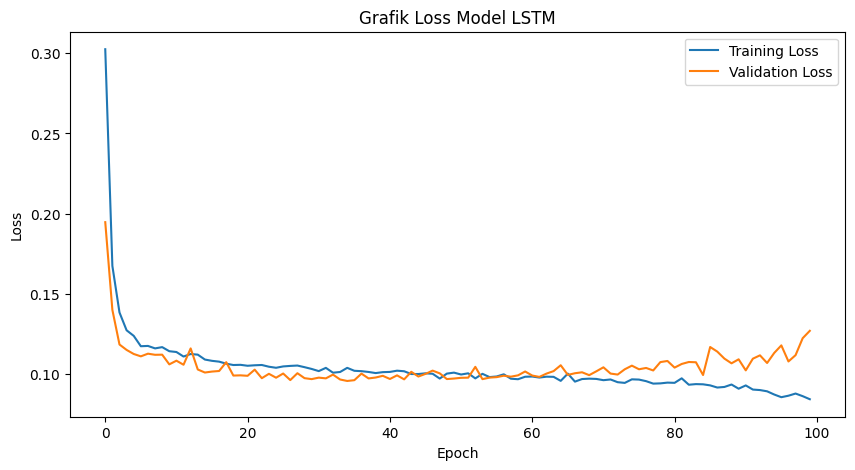

In [ ]:
# GRAFIK LOSS

plt.figure(figsize=(10,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Grafik Loss Model LSTM")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

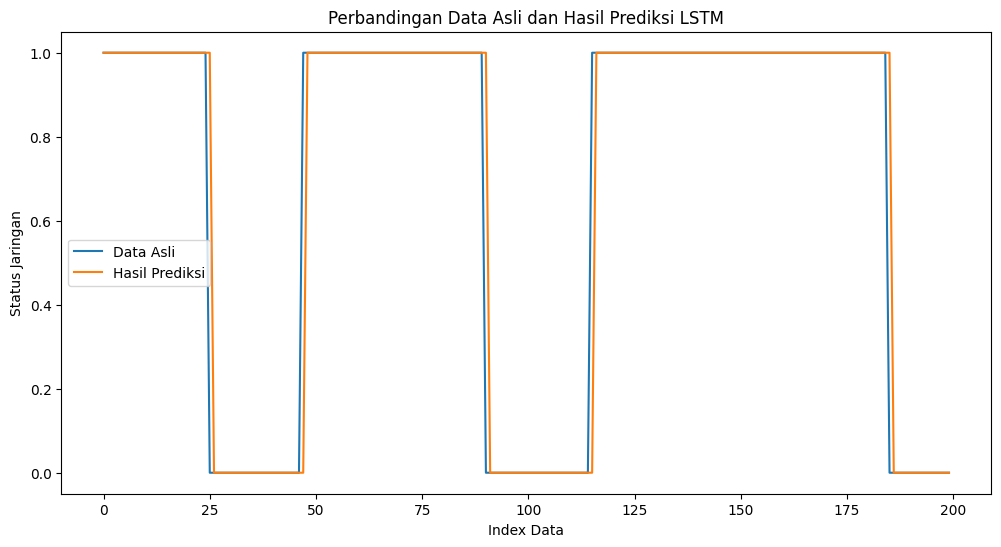

In [ ]:
# VISUALISASI HASIL PREDIKSI

plt.figure(figsize=(12,6))

plt.plot(y_test[:200], label="Data Asli")
plt.plot(y_pred[:200], label="Hasil Prediksi")

plt.title("Perbandingan Data Asli dan Hasil Prediksi LSTM")
plt.xlabel("Index Data")
plt.ylabel("Status Jaringan")
plt.legend()
plt.show()